# 🤖 Modelo1_V1_Daniele — Baseline + Learning Curve (PASO 2)
### Reto de Inteligencia Artificial — Detección de Audio Spoofing
**Dataset:** ASVspoof2019 — Logical Access (LA) — Conjunto de Entrenamiento  
**Autor:** Daniele  
**Versión:** V1  

---
## Objetivo de este Notebook

Este notebook ejecuta el **Paso 2** del plan estratégico:

1. Reproduce el mismo **pipeline de datos** del EDA (undersampling + split Train/Test) con la misma semilla.
2. Entrena **3 algoritmos baseline**: Random Forest, XGBoost y Red Neuronal (MLP).
3. Aplica **Validación Cruzada Estratificada (5-Fold)** para obtener métricas robustas.
4. Calcula la **Learning Curve** de cada modelo para descubrir a partir de qué número de registros el rendimiento hace *plateau*.
5. Realiza un **Análisis de Overfitting** comparando métricas de Train vs. Validación.
6. Compara los 3 modelos y extrae conclusiones para el **Paso 3**.

El resultado de este notebook guiará la optimización del tamaño de muestra en los modelos siguientes.

---
## 📝 PARA TU BLOC DE NOTAS — JUSTIFICACIÓN GLOBAL DEL PASO 2

**¿Por qué entrenar 3 algoritmos distintos en la fase baseline?**  
Cada algoritmo tiene sesgos inductivos diferentes:
- **Random Forest:** Ensemble de árboles de decisión con bagging. Robusto al overfitting por construcción. Ideal como baseline sólido.
- **XGBoost:** Gradient Boosting optimizado. Tiende a rendir mejor en datos tabulares con características bien diseñadas. Más propenso a overfitting si no se regulariza.
- **Red Neuronal (MLP):** Modelo de mayor capacidad, puede capturar relaciones no lineales complejas. Requiere más datos y es el más propenso al overfitting.

Al entrenarlos con los **mismos datos y la misma validación cruzada**, podemos comparar de forma justa y elegir el algoritmo óptimo para el Paso 3.

**¿Por qué Validación Cruzada Estratificada (5-Fold)?**  
Con solo 4.000 registros de train, una única partición Train/Val introduce alta varianza. El 5-Fold StratifiedKFold:
1. Garantiza que cada fold mantiene la proporción de clases (50/50 bonafide/spoof).
2. Usa el 100% de los datos para entrenamiento y validación de forma rotativa.
3. Nos da una estimación estadísticamente más robusta del rendimiento real.

**¿Para qué sirve la Learning Curve?**  
La Learning Curve nos dice cuántos datos necesita cada modelo para aprender. Si la curva de validación llega al plateau con, por ejemplo, 2.000 muestras, significa que añadir más datos no mejora el rendimiento. Esto justifica reducir el tamaño de muestra en el Paso 3 sin sacrificar calidad.

In [1]:
# ============================================================
#  BLOQUE 1 — IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-learn ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# --- XGBoost ---
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('⚠️  XGBoost no instalado. Instalar con: pip install xgboost')
    XGB_AVAILABLE = False

# --- Configuración estética ---
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titleweight']   = 'bold'
plt.rcParams['axes.titlesize']     = 12

# --- Parámetros globales (IDÉNTICOS al EDA para reproducibilidad) ---
RANDOM_STATE  = 42
N_PER_CLASS   = 2500   # registros por clase tras undersampling
TEST_SIZE     = 0.20   # 80% train / 20% test — sellado hasta evaluación final
N_FOLDS       = 5      # folds para validación cruzada
DATA_PATH     = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

print('✅ Librerías cargadas correctamente.')
print(f'   RANDOM_STATE={RANDOM_STATE} | N_PER_CLASS={N_PER_CLASS} | N_FOLDS={N_FOLDS}')
print(f'   XGBoost disponible: {XGB_AVAILABLE}')

✅ Librerías cargadas correctamente.
   RANDOM_STATE=42 | N_PER_CLASS=2500 | N_FOLDS=5
   XGBoost disponible: True


---
## SECCIÓN 1 — Reproducción del Pipeline de Datos del EDA

> Reproducimos **exactamente** el mismo proceso del `Modelo_EDA_Daniele.ipynb` con la misma semilla (`RANDOM_STATE=42`).  
> Esto garantiza que trabajamos con **los mismos 4.000 registros de train** que se analizaron en el Paso 1.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué reproducimos el pipeline en lugar de guardar y cargar un CSV?**  
Reproducir el pipeline con la misma semilla garantiza:
1. **Trazabilidad:** Cualquier persona puede verificar de dónde vienen los datos.
2. **Consistencia:** Si el dataset original cambia, el pipeline se actualiza automáticamente.
3. **Prevención de Data Leakage:** Confirmamos que el test set sigue sellado (no fue visto durante el EDA).

Las features seleccionadas son todas las columnas numéricas excepto `file_name`, `attack_id` y `label`.

In [2]:
# ============================================================
#  BLOQUE 2 — CARGA Y REPRODUCCIÓN DEL PIPELINE DE DATOS
# ============================================================

# -- 2.1 Carga del dataset completo --
df_full = pd.read_csv(DATA_PATH)
print(f'Dataset completo: {df_full.shape[0]:,} filas × {df_full.shape[1]} columnas')

# -- 2.2 Undersampling estratificado por attack_id (IDÉNTICO al EDA) --
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

# Undersample BONAFIDE
n_bonafide    = min(len(df_bonafide), N_PER_CLASS)
df_bon_sample = df_bonafide.sample(n=n_bonafide, random_state=RANDOM_STATE)

# Undersample SPOOF — proporcional por attack_id
attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_spoof_total = N_PER_CLASS
n_per_attack  = (proportions * n_spoof_total).astype(int)
deficit       = n_spoof_total - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    spoof_samples.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_spoof_sample = pd.concat(spoof_samples)
df_balanced = pd.concat([df_bon_sample, df_spoof_sample]).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

# -- 2.3 Definición de Features y Target --
FEATURE_COLS = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
TARGET_COL   = 'label'

X = df_balanced[FEATURE_COLS]
y = df_balanced[TARGET_COL]

# -- 2.4 Separación Train / Test (SELLADO) --
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# -- 2.5 Codificación de etiquetas: bonafide=0, spoof=1 --
le = LabelEncoder()
le.fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('=' * 60)
print('PIPELINE DE DATOS REPRODUCIDO')
print('=' * 60)
print(f'  Dataset balanceado : {df_balanced.shape[0]:,} filas')
print(f'  Features           : {len(FEATURE_COLS)}')
print(f'  Train              : {X_train.shape[0]:,} filas')
print(f'  Test (SELLADO)     : {X_test.shape[0]:,} filas')
print()
print('Distribución de clases en TRAIN:')
print(y_train.value_counts().to_string())
print('\nDistribución de clases en TEST:')
print(y_test.value_counts().to_string())
print('\n⚠️  El conjunto de TEST queda SELLADO. No se usará hasta la evaluación final.')

Dataset completo: 25,380 filas × 37 columnas
PIPELINE DE DATOS REPRODUCIDO
  Dataset balanceado : 5,000 filas
  Features           : 34
  Train              : 4,000 filas
  Test (SELLADO)     : 1,000 filas

Distribución de clases en TRAIN:
label
spoof       2000
bonafide    2000

Distribución de clases en TEST:
label
bonafide    500
spoof       500

⚠️  El conjunto de TEST queda SELLADO. No se usará hasta la evaluación final.


---
## SECCIÓN 2 — Definición de los 3 Modelos Baseline

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué estos hiperparámetros iniciales?**  
Estamos en la fase **baseline**: el objetivo NO es maximizar el rendimiento, sino establecer un punto de referencia honesto que refleje el comportamiento natural de cada algoritmo.

- **Random Forest:** `n_estimators=100` es el estándar de la industria. Suficientes árboles para estabilidad, sin sobrecargar el cómputo.
- **XGBoost:** `n_estimators=200, max_depth=5, learning_rate=0.1`. Parámetros moderados que evitan el overfitting extremo en la primera iteración.
- **MLP:** `(64, 32)` — dos capas ocultas de tamaño decreciente. Arquitectura conservadora para 34 features. `max_iter=300` para asegurar convergencia.

El MLP incluye un `StandardScaler` dentro de un `Pipeline` porque las redes neuronales son sensibles a la escala de las features. Random Forest y XGBoost son invariantes a la escala, por lo que no lo necesitan.

In [3]:
# ============================================================
#  BLOQUE 3 — DEFINICIÓN DE LOS 3 MODELOS BASELINE
# ============================================================

# -- Modelo 1: Random Forest --
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,         # Sin límite → puede overfit, lo mediremos
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# -- Modelo 2: XGBoost --
if XGB_AVAILABLE:
    model_xgb = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
else:
    model_xgb = None

# -- Modelo 3: Red Neuronal (MLP) — dentro de un Pipeline con escalado --
model_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,           # Regularización L2 suave
        max_iter=300,
        early_stopping=True,    # Detención temprana para reducir overfitting
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    ))
])

# -- Diccionario de modelos --
models = {
    'Random Forest': model_rf,
    'XGBoost'      : model_xgb,
    'Red Neuronal' : model_mlp
}
if not XGB_AVAILABLE:
    models.pop('XGBoost')

print('✅ Modelos definidos:')
for name, m in models.items():
    print(f'   • {name}: {type(m).__name__}')

✅ Modelos definidos:
   • Random Forest: RandomForestClassifier
   • XGBoost: XGBClassifier
   • Red Neuronal: Pipeline


---
## SECCIÓN 3 — Validación Cruzada Estratificada (5-Fold)

Evaluamos cada modelo con **StratifiedKFold (k=5)** sobre el conjunto de Train.  
Métricas calculadas: Accuracy, Precision, Recall, F1-Score, AUC-ROC (tanto en Train como en Validación).

### 📝 PARA TU BLOC DE NOTAS

**¿Qué nos dice el gap Train vs. Validación?**

| Situación | Train | Val | Diagnóstico |
|-----------|-------|-----|-------------|
| **Underfitting** | Bajo | Bajo | El modelo es demasiado simple. Necesita más features o más capacidad. |
| **Overfitting leve** | Alto | Mediano | Normal en baselines. Regularización puede ayudar. |
| **Overfitting severo** | ~1.0 | Bajo | El modelo memorizó el train. Requiere regularización fuerte o menos features. |
| **Buen ajuste** | Alto | Alto (similar) | El modelo generaliza bien. |

**¿Por qué usamos AUC-ROC además de Accuracy?**  
En detección de fraude/spoofing, el coste de un Falso Negativo (spoof no detectado) es mayor que el de un Falso Positivo. El AUC-ROC evalúa la capacidad del modelo a todos los umbrales de decisión, siendo más informativo que la Accuracy sola.

In [4]:
# ============================================================
#  BLOQUE 4 — VALIDACIÓN CRUZADA 5-FOLD
# ============================================================

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

cv_results = {}

for name, model in models.items():
    print(f'\n{'='*55}')
    print(f'  Entrenando: {name}')
    print(f'{'='*55}')
    t0 = time.time()

    # cross_validate devuelve métricas de train Y test (val) por fold
    cv_out = cross_validate(
        model, X_train, y_train_enc,
        cv=cv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1
    )
    elapsed = time.time() - t0
    cv_results[name] = cv_out

    # -- Resumen de métricas --
    print(f'  Tiempo de entrenamiento: {elapsed:.1f}s')
    print(f'  {'Métrica':<20} {'Train (μ ± σ)':<22} {'Val (μ ± σ)':<22} {'GAP':>8}')
    print(f'  {'-'*74}')
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr_mean = cv_out[f'train_{metric}'].mean()
        tr_std  = cv_out[f'train_{metric}'].std()
        va_mean = cv_out[f'test_{metric}'].mean()
        va_std  = cv_out[f'test_{metric}'].std()
        gap     = tr_mean - va_mean
        flag    = '⚠️' if gap > 0.05 else '✅'
        print(f'  {metric.capitalize():<20} {tr_mean:.4f} ± {tr_std:.4f}      '
              f'{va_mean:.4f} ± {va_std:.4f}  {gap:+.4f} {flag}')

print('\n✅ Validación cruzada completada para todos los modelos.')


  Entrenando: Random Forest
  Tiempo de entrenamiento: 8.2s
  Métrica              Train (μ ± σ)          Val (μ ± σ)                 GAP
  --------------------------------------------------------------------------
  Accuracy             1.0000 ± 0.0000      0.9252 ± 0.0058  +0.0748 ⚠️
  Precision            1.0000 ± 0.0000      0.9489 ± 0.0082  +0.0511 ⚠️
  Recall               1.0000 ± 0.0000      0.8990 ± 0.0119  +0.1010 ⚠️
  F1                   1.0000 ± 0.0000      0.9232 ± 0.0063  +0.0768 ⚠️
  Roc_auc              1.0000 ± 0.0000      0.9796 ± 0.0045  +0.0204 ✅

  Entrenando: XGBoost
  Tiempo de entrenamiento: 5.3s
  Métrica              Train (μ ± σ)          Val (μ ± σ)                 GAP
  --------------------------------------------------------------------------
  Accuracy             1.0000 ± 0.0000      0.9463 ± 0.0067  +0.0537 ⚠️
  Precision            1.0000 ± 0.0000      0.9637 ± 0.0068  +0.0363 ✅
  Recall               1.0000 ± 0.0000      0.9275 ± 0.0139  +0.0725 ⚠️


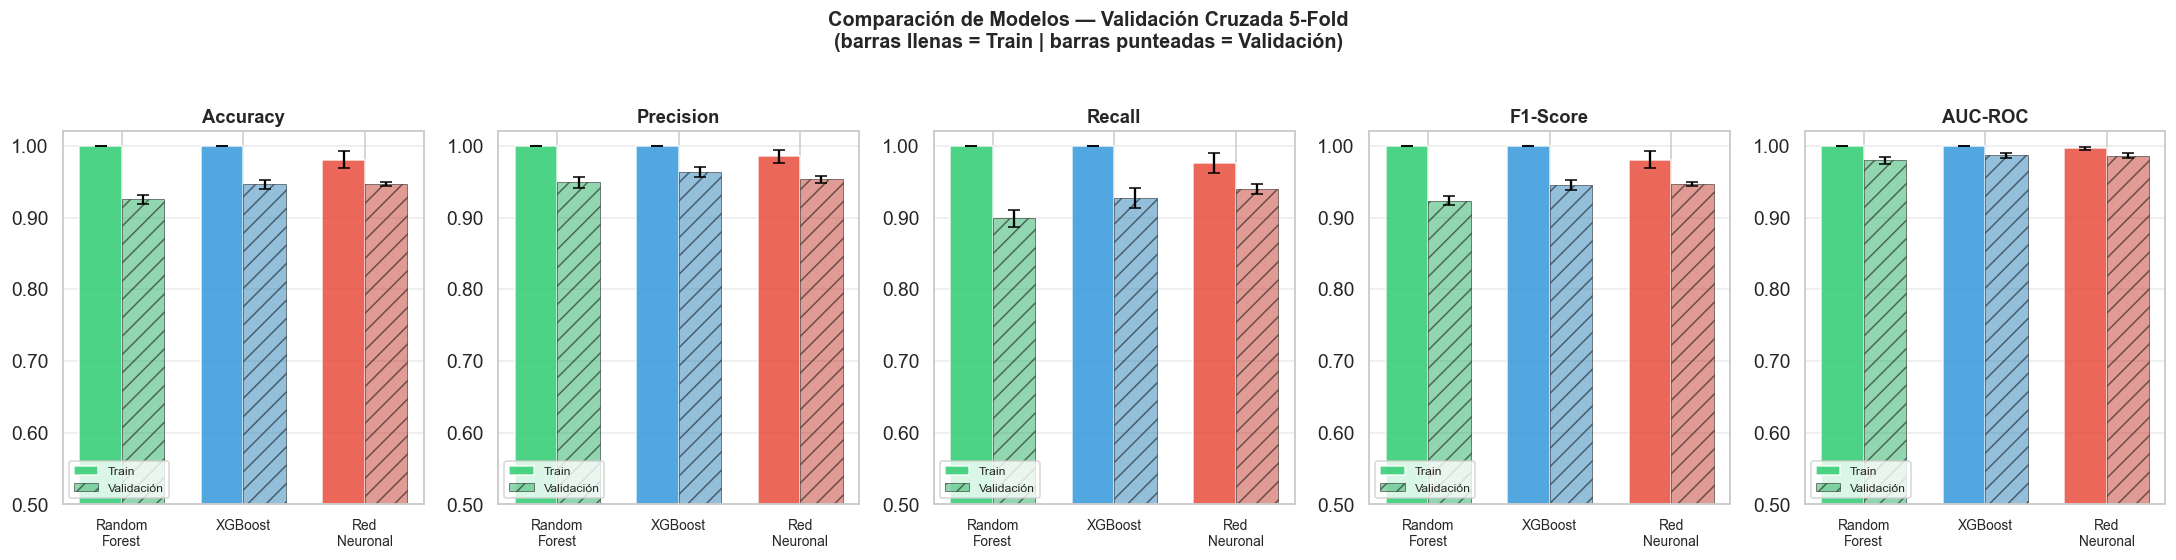

📊 Gráfico guardado: modelo1_comparacion_cv.png


In [5]:
# ============================================================
#  BLOQUE 5 — VISUALIZACIÓN: COMPARACIÓN DE MODELOS (CV)
# ============================================================

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names     = list(models.keys())
colors_train    = ['#2ecc71', '#3498db', '#e74c3c']
colors_val      = ['#27ae60', '#2980b9', '#c0392b']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
fig.suptitle('Comparación de Modelos — Validación Cruzada 5-Fold\n(barras llenas = Train | barras punteadas = Validación)',
             fontsize=13, fontweight='bold', y=1.02)

x      = np.arange(len(model_names))
width  = 0.35

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    train_means = [cv_results[n][f'train_{metric}'].mean() for n in model_names]
    val_means   = [cv_results[n][f'test_{metric}'].mean()  for n in model_names]
    train_stds  = [cv_results[n][f'train_{metric}'].std()  for n in model_names]
    val_stds    = [cv_results[n][f'test_{metric}'].std()   for n in model_names]

    bars_tr = ax.bar(x - width/2, train_means, width, label='Train',
                     color=colors_train[:len(model_names)], alpha=0.85,
                     yerr=train_stds, capsize=4)
    bars_va = ax.bar(x + width/2, val_means, width, label='Validación',
                     color=colors_val[:len(model_names)], alpha=0.5,
                     hatch='//', edgecolor='black', linewidth=0.6,
                     yerr=val_stds, capsize=4)

    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
    ax.set_ylim(0.5, 1.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo1_comparacion_cv.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo1_comparacion_cv.png')

---
## SECCIÓN 4 — Análisis de Overfitting

Calculamos el **GAP Train - Validación** para cada métrica y modelo.  
Un GAP > 0.05 indica overfitting significativo que deberemos corregir.

### 📝 PARA TU BLOC DE NOTAS

**¿Cómo interpretamos el análisis de overfitting de esta primera iteración?**

Esperamos que en este baseline:
- **Random Forest sin límite de profundidad (`max_depth=None`)** tenga overfitting severo en Train (puede llegar a 1.0) pero buena generalización en Validación gracias al bagging.
- **XGBoost** tendrá un gap moderado, ya que el boosting puede overfit con muchos estimadores.
- **Red Neuronal (MLP)** con `early_stopping=True` debería tener el gap más controlado, aunque su capacidad la hace propensa a memorizar si no hay suficientes datos.

El análisis de overfitting de esta iteración nos justificará en el Paso 3 qué tipo de regularización aplicar a cada modelo.

In [6]:
# ============================================================
#  BLOQUE 6 — TABLA DE ANÁLISIS DE OVERFITTING
# ============================================================

print('=' * 80)
print('ANÁLISIS DE OVERFITTING — GAP (Train - Validación) por Modelo y Métrica')
print('=' * 80)

overfitting_data = []
for name in model_names:
    row = {'Modelo': name}
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr = cv_results[name][f'train_{metric}'].mean()
        va = cv_results[name][f'test_{metric}'].mean()
        gap = tr - va
        row[f'{metric}_train'] = tr
        row[f'{metric}_val']   = va
        row[f'{metric}_gap']   = gap
    overfitting_data.append(row)

df_overfit = pd.DataFrame(overfitting_data).set_index('Modelo')

print(f'\n{"":<18} {"Accuracy":>18} {"Precision":>18} {"Recall":>18} {"F1":>18} {"AUC-ROC":>18}')
print(f'{"":<18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18}')
print('-' * 108)
for name in model_names:
    row_str = f'{name:<18}'
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr  = df_overfit.loc[name, f'{metric}_train']
        va  = df_overfit.loc[name, f'{metric}_val']
        gap = df_overfit.loc[name, f'{metric}_gap']
        flag = '⚠' if gap > 0.05 else ' '
        row_str += f' {tr:.3f}|{va:.3f}|{gap:+.3f}{flag}'
    print(row_str)

print('\nLeyenda: ⚠ = GAP > 0.05 (overfitting significativo)  |  Sin marca = aceptable')

# -- Resumen de diagnóstico --
print('\n' + '=' * 80)
print('DIAGNÓSTICO DE OVERFITTING')
print('=' * 80)
for name in model_names:
    gaps = [df_overfit.loc[name, f'{m}_gap'] for m in ['accuracy', 'f1', 'roc_auc']]
    avg_gap = np.mean(gaps)
    if avg_gap > 0.10:
        diag = '🔴 OVERFITTING SEVERO — Requiere regularización fuerte'
    elif avg_gap > 0.05:
        diag = '🟡 OVERFITTING MODERADO — Regularización recomendada'
    else:
        diag = '🟢 AJUSTE ACEPTABLE — Buen baseline'
    print(f'  {name:<18}: GAP medio (Acc/F1/AUC) = {avg_gap:+.4f} → {diag}')

ANÁLISIS DE OVERFITTING — GAP (Train - Validación) por Modelo y Métrica

                             Accuracy          Precision             Recall                 F1            AUC-ROC
                    Train | Val | Gap  Train | Val | Gap  Train | Val | Gap  Train | Val | Gap  Train | Val | Gap
------------------------------------------------------------------------------------------------------------
Random Forest      1.000|0.925|+0.075⚠ 1.000|0.949|+0.051⚠ 1.000|0.899|+0.101⚠ 1.000|0.923|+0.077⚠ 1.000|0.980|+0.020 
XGBoost            1.000|0.946|+0.054⚠ 1.000|0.964|+0.036  1.000|0.927|+0.073⚠ 1.000|0.945|+0.055⚠ 1.000|0.987|+0.013 
Red Neuronal       0.981|0.947|+0.034  0.985|0.953|+0.032  0.976|0.940|+0.036  0.981|0.947|+0.034  0.997|0.986|+0.011 

Leyenda: ⚠ = GAP > 0.05 (overfitting significativo)  |  Sin marca = aceptable

DIAGNÓSTICO DE OVERFITTING
  Random Forest     : GAP medio (Acc/F1/AUC) = +0.0573 → 🟡 OVERFITTING MODERADO — Regularización recomendada
  XGBoost        

---
## SECCIÓN 5 — Learning Curves

La **Learning Curve** muestra cómo evoluciona el rendimiento del modelo al aumentar la cantidad de datos de entrenamiento.  
La ejecutamos para cada modelo usando el conjunto de Train completo (4.000 muestras).

### 📝 PARA TU BLOC DE NOTAS

**¿Cómo leer una Learning Curve?**

```
Rendimiento
  ↑
  |   Train ────────────────────
  |   Val  ·  ·  ·  ·  ──────────
  |           ↑
  |           Punto de plateau
  └──────────────────────────────→ N muestras
```

- **Curva de Train descendente:** normal. Con más datos el modelo no puede memorizar tan fácil → menos overfitting.
- **Curva de Validación ascendente:** el modelo mejora con más datos.
- **Plateau de Validación:** a partir de este punto, añadir más datos no mejora el rendimiento. Este es el **tamaño óptimo de muestra**.
- **GAP persistente entre Train y Val:** indica underfitting o overfitting estructural que no se resuelve con más datos (necesita cambiar el modelo).

**¿Qué decisión tomamos con esta información?**  
Si el plateau ocurre antes de 4.000 muestras (ej. con 2.000), en el Paso 3 reduciremos el dataset al tamaño óptimo. Esto reduce el tiempo de entrenamiento y evita el overfitting por exceso de datos.

In [7]:
# ============================================================
#  BLOQUE 7 — CÁLCULO DE LEARNING CURVES
# ============================================================

# Tamaños de muestra a evaluar (10% → 100% del train)
TRAIN_SIZES = np.linspace(0.10, 1.0, 10)

lc_results = {}

for name, model in models.items():
    print(f'Calculando Learning Curve para {name}...', end=' ')
    t0 = time.time()

    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train_enc,
        cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=TRAIN_SIZES,
        scoring='f1',
        n_jobs=-1,
        return_times=False
    )

    lc_results[name] = {
        'sizes'       : train_sizes_abs,
        'train_mean'  : train_scores.mean(axis=1),
        'train_std'   : train_scores.std(axis=1),
        'val_mean'    : val_scores.mean(axis=1),
        'val_std'     : val_scores.std(axis=1)
    }

    elapsed = time.time() - t0
    print(f'✅ {elapsed:.1f}s')

print('\n✅ Learning Curves calculadas para todos los modelos.')

Calculando Learning Curve para Random Forest... ✅ 8.2s
Calculando Learning Curve para XGBoost... ✅ 7.9s
Calculando Learning Curve para Red Neuronal... ✅ 5.6s

✅ Learning Curves calculadas para todos los modelos.


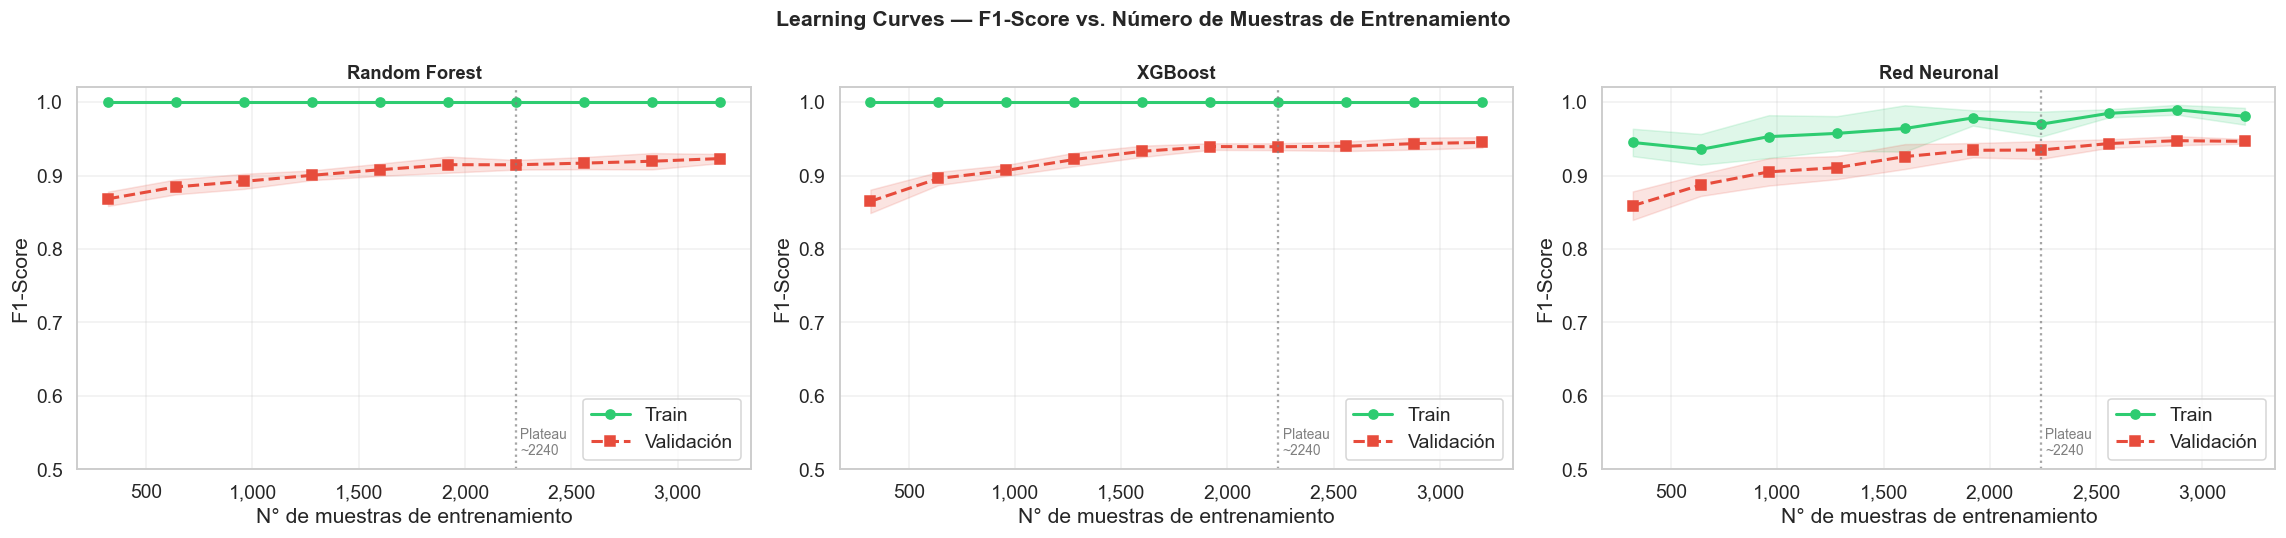

📊 Gráfico guardado: modelo1_learning_curves.png


In [8]:
# ============================================================
#  BLOQUE 8 — VISUALIZACIÓN DE LEARNING CURVES
# ============================================================

fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
if len(models) == 1:
    axes = [axes]

fig.suptitle('Learning Curves — F1-Score vs. Número de Muestras de Entrenamiento',
             fontsize=14, fontweight='bold')

palette = {'train': '#2ecc71', 'val': '#e74c3c'}

for ax, name in zip(axes, model_names):
    lc = lc_results[name]
    sizes      = lc['sizes']
    tr_mean    = lc['train_mean']
    tr_std     = lc['train_std']
    val_mean   = lc['val_mean']
    val_std    = lc['val_std']

    # -- Curvas --
    ax.plot(sizes, tr_mean,  'o-', color=palette['train'], linewidth=2.0, label='Train')
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=palette['train'])

    ax.plot(sizes, val_mean, 's--', color=palette['val'], linewidth=2.0, label='Validación')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color=palette['val'])

    # -- Detectar plateau (primer punto donde ΔVal < 0.005) --
    plateau_idx = None
    for i in range(1, len(val_mean)):
        if abs(val_mean[i] - val_mean[i-1]) < 0.005:
            plateau_idx = i
            break
    if plateau_idx:
        ax.axvline(sizes[plateau_idx], color='gray', linestyle=':', alpha=0.7, linewidth=1.5)
        ax.text(sizes[plateau_idx] + 20, 0.52,
                f'Plateau\n~{sizes[plateau_idx]:.0f}',
                fontsize=9, color='gray', ha='left')

    ax.set_title(name)
    ax.set_xlabel('N° de muestras de entrenamiento')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0.50, 1.02)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('modelo1_learning_curves.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo1_learning_curves.png')

In [9]:
# ============================================================
#  BLOQUE 9 — ANÁLISIS NUMÉRICO DEL PLATEAU
# ============================================================

print('=' * 70)
print('ANÁLISIS DEL PLATEAU — ¿A partir de cuántas muestras se estanca el modelo?')
print('=' * 70)

for name in model_names:
    lc        = lc_results[name]
    sizes     = lc['sizes']
    val_mean  = lc['val_mean']

    # Plateau: primer punto donde la mejora marginal < 0.5%
    plateau_idx  = None
    plateau_size = None
    for i in range(1, len(val_mean)):
        if abs(val_mean[i] - val_mean[i-1]) < 0.005:
            plateau_idx  = i
            plateau_size = sizes[i]
            break

    best_f1     = val_mean.max()
    f1_at_start = val_mean[0]
    improvement = best_f1 - f1_at_start

    print(f'\n  📌 {name}')
    print(f'     F1 con {int(sizes[0]):,} muestras  : {f1_at_start:.4f}')
    print(f'     F1 con {int(sizes[-1]):,} muestras: {val_mean[-1]:.4f}')
    print(f'     Mejor F1 (Val)            : {best_f1:.4f}')
    print(f'     Ganancia total            : {improvement:+.4f}')
    if plateau_size:
        print(f'     Plateau detectado en      : ~{int(plateau_size):,} muestras')
        pct = 100 * plateau_size / sizes[-1]
        print(f'     → Usar el {pct:.0f}% del train sería suficiente')
    else:
        print(f'     → No se detectó plateau claro. Más datos podrían mejorar el modelo.')

print('\n' + '=' * 70)
print('CONCLUSIÓN PARA EL PASO 3:')
print('=' * 70)
print('El tamaño óptimo de muestra para el Paso 3 se determinará tomando el')
print('plateau del mejor modelo. Buscaremos el mínimo N donde Val-F1 sea')
print('≥ 98% del Val-F1 máximo, reduciendo el cómputo sin sacrificar calidad.')

ANÁLISIS DEL PLATEAU — ¿A partir de cuántas muestras se estanca el modelo?

  📌 Random Forest
     F1 con 320 muestras  : 0.8684
     F1 con 3,200 muestras: 0.9232
     Mejor F1 (Val)            : 0.9232
     Ganancia total            : +0.0548
     Plateau detectado en      : ~2,240 muestras
     → Usar el 70% del train sería suficiente

  📌 XGBoost
     F1 con 320 muestras  : 0.8649
     F1 con 3,200 muestras: 0.9452
     Mejor F1 (Val)            : 0.9452
     Ganancia total            : +0.0803
     Plateau detectado en      : ~2,240 muestras
     → Usar el 70% del train sería suficiente

  📌 Red Neuronal
     F1 con 320 muestras  : 0.8590
     F1 con 3,200 muestras: 0.9466
     Mejor F1 (Val)            : 0.9476
     Ganancia total            : +0.0885
     Plateau detectado en      : ~2,240 muestras
     → Usar el 70% del train sería suficiente

CONCLUSIÓN PARA EL PASO 3:
El tamaño óptimo de muestra para el Paso 3 se determinará tomando el
plateau del mejor modelo. Buscaremos el 

---
## SECCIÓN 6 — Evaluación Final en Test (SOLO LECTURA — No usar para optimizar)

> ⚠️ **ADVERTENCIA:** Esta sección **solo debe ejecutarse una vez** al final, para reportar el rendimiento real del modelo.  
> Usarla para ajustar hiperparámetros constituye **Data Leakage**.

Entrenamos cada modelo con **todo el Train** y evaluamos contra el **Test sellado**.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué evaluamos en Test si tenemos la validación cruzada?**  
La validación cruzada usa datos de Train para estimar el rendimiento. El test set es el juicio final: datos que el modelo nunca vio, que replican el escenario real de producción. La comparación entre CV-Val y Test nos dice si nuestra estimación era realista.

- **CV-Val ≈ Test:** Estimación correcta. El modelo generaliza.
- **CV-Val >> Test:** Hubo fuga de información (Data Leakage) en algún paso.
- **CV-Val << Test:** Raro. Puede ocurrir si el test set es particularmente fácil.

In [10]:
# ============================================================
#  BLOQUE 10 — EVALUACIÓN FINAL EN TEST
#  ⚠️  EJECUTAR UNA SOLA VEZ — Solo para reporte final
# ============================================================

test_results = {}

for name, model in models.items():
    print(f'\n{'='*55}')
    print(f'  Evaluando en TEST: {name}')
    print(f'{'='*55}')

    # Entrenamos con TODO el train
    model.fit(X_train, y_train_enc)

    # Predicciones en test
    y_pred     = model.predict(X_test)
    y_pred_proba = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, 'predict_proba') else None
    )

    metrics = {
        'accuracy' : accuracy_score(y_test_enc, y_pred),
        'precision': precision_score(y_test_enc, y_pred),
        'recall'   : recall_score(y_test_enc, y_pred),
        'f1'       : f1_score(y_test_enc, y_pred),
        'roc_auc'  : roc_auc_score(y_test_enc, y_pred_proba) if y_pred_proba is not None else np.nan
    }
    test_results[name] = metrics

    print(f'  Accuracy : {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall   : {metrics["recall"]:.4f}')
    print(f'  F1-Score : {metrics["f1"]:.4f}')
    print(f'  AUC-ROC  : {metrics["roc_auc"]:.4f}')

    print(f'\n  Reporte completo:')
    print(classification_report(y_test_enc, y_pred,
                                target_names=['bonafide', 'spoof']))


  Evaluando en TEST: Random Forest
  Accuracy : 0.9330
  Precision: 0.9558
  Recall   : 0.9080
  F1-Score : 0.9313
  AUC-ROC  : 0.9785

  Reporte completo:
              precision    recall  f1-score   support

    bonafide       0.91      0.96      0.93       500
       spoof       0.96      0.91      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000


  Evaluando en TEST: XGBoost
  Accuracy : 0.9550
  Precision: 0.9691
  Recall   : 0.9400
  F1-Score : 0.9543
  AUC-ROC  : 0.9897

  Reporte completo:
              precision    recall  f1-score   support

    bonafide       0.94      0.97      0.96       500
       spoof       0.97      0.94      0.95       500

    accuracy                           0.95      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.96      0.95      0.95      1000


  Evaluando en TEST: Red Neuronal
  A

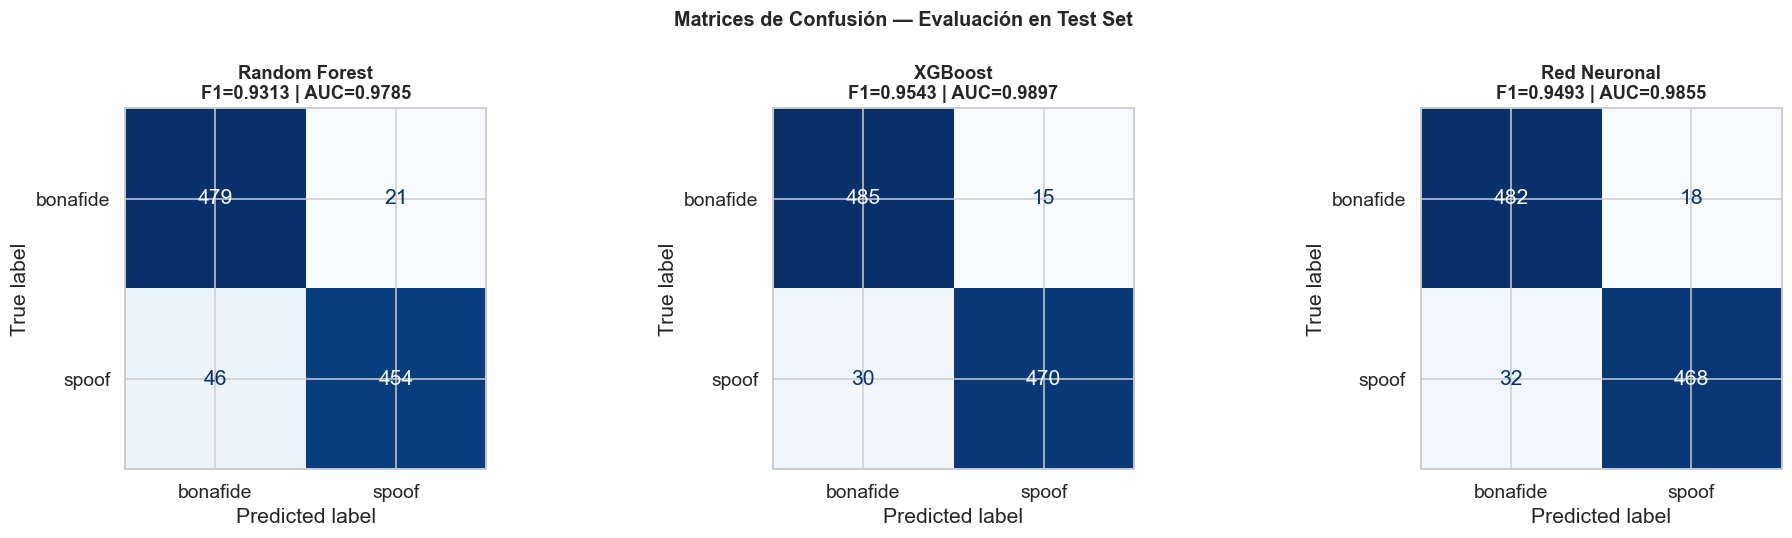

📊 Gráfico guardado: modelo1_matrices_confusion.png


In [11]:
# ============================================================
#  BLOQUE 11 — MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

fig.suptitle('Matrices de Confusión — Evaluación en Test Set',
             fontsize=13, fontweight='bold')

for ax, name in zip(axes, model_names):
    model  = models[name]
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test_enc, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['bonafide', 'spoof'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={test_results[name]["f1"]:.4f} | AUC={test_results[name]["roc_auc"]:.4f}')

plt.tight_layout()
plt.savefig('modelo1_matrices_confusion.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo1_matrices_confusion.png')

In [12]:
# ============================================================
#  BLOQUE 12 — COMPARACIÓN CV-Val vs. Test
# ============================================================

print('=' * 75)
print('COMPARACIÓN: Validación Cruzada vs. Test Set (Estimación vs. Realidad)')
print('=' * 75)
print(f'  {"Modelo":<18} {"CV-Val F1":>12} {"Test F1":>12} {"Diferencia":>12} {"CV-Val AUC":>12} {"Test AUC":>12}')
print('-' * 75)

for name in model_names:
    cv_f1   = cv_results[name]['test_f1'].mean()
    test_f1 = test_results[name]['f1']
    diff_f1 = test_f1 - cv_f1

    cv_auc   = cv_results[name]['test_roc_auc'].mean()
    test_auc = test_results[name]['roc_auc']

    flag = '✅' if abs(diff_f1) < 0.03 else ('📈' if diff_f1 > 0 else '⚠️')
    print(f'  {name:<18} {cv_f1:>12.4f} {test_f1:>12.4f} {diff_f1:>+12.4f} {cv_auc:>12.4f} {test_auc:>12.4f}  {flag}')

print('\nLeyenda: ✅ CV ≈ Test (estimación confiable) | ⚠️ CV >> Test (posible leakage)')

COMPARACIÓN: Validación Cruzada vs. Test Set (Estimación vs. Realidad)
  Modelo                CV-Val F1      Test F1   Diferencia   CV-Val AUC     Test AUC
---------------------------------------------------------------------------
  Random Forest            0.9232       0.9313      +0.0081       0.9796       0.9785  ✅
  XGBoost                  0.9452       0.9543      +0.0091       0.9866       0.9897  ✅
  Red Neuronal             0.9466       0.9493      +0.0027       0.9861       0.9855  ✅

Leyenda: ✅ CV ≈ Test (estimación confiable) | ⚠️ CV >> Test (posible leakage)


---
## SECCIÓN 7 — Resumen y Conclusiones del PASO 2

### 📝 PARA TU BLOC DE NOTAS — CONCLUSIONES GLOBALES

**¿Qué aprendimos de esta primera iteración (Paso 2)?**

1. **Rendimiento Baseline:** Los 3 modelos establecen el punto de referencia. Cualquier modelo del Paso 3 debe superar estas métricas para justificar la optimización.

2. **Análisis de Overfitting:**
   - Si Random Forest tiene Train~1.0 y Val~0.9+ → Overfitting controlado por bagging. En el Paso 3 podemos limitar `max_depth` para reducir el gap.
   - Si XGBoost tiene un gap moderado → Reducir `n_estimators` o aumentar `reg_lambda` en el Paso 3.
   - Si MLP tiene buen balance gracias a `early_stopping` → Arquitectura base aceptable para el Paso 3.

3. **Learning Curve — Tamaño Óptimo:**
   - El plateau nos dice el N óptimo para el Paso 3.
   - Si el plateau está en ~2.000 muestras → En el Paso 3 usaremos ese tamaño.
   - Si el plateau NO se detectó → Los modelos se benefician de más datos. Considerar usar el dataset completo sin undersampling extremo.

4. **Mejor Algoritmo Provisional:**
   - El modelo con mayor F1 en Validación + menor gap Train-Val es el candidato para el Paso 4 (Prueba de Fuego).

5. **Próximos Pasos (Paso 3):**
   - Optimizar el tamaño de muestra según la Learning Curve.
   - Aplicar regularización al modelo con mayor overfitting.
   - Calcular Feature Importance para selección de variables.
   - Comparar Modelo2 vs. Modelo3 hasta encontrar el óptimo.

In [13]:
# ============================================================
#  BLOQUE 13 — RANKING FINAL DE MODELOS
# ============================================================

print('=' * 70)
print('RANKING FINAL DE MODELOS BASELINE — PASO 2')
print('=' * 70)

# Criterio de ranking: F1 de validación cruzada (no usamos test para elegir)
ranking = []
for name in model_names:
    cv_f1      = cv_results[name]['test_f1'].mean()
    cv_auc     = cv_results[name]['test_roc_auc'].mean()
    cv_recall  = cv_results[name]['test_recall'].mean()
    train_f1   = cv_results[name]['train_f1'].mean()
    gap        = train_f1 - cv_f1
    test_f1    = test_results[name]['f1']

    # Plateau
    val_mean    = lc_results[name]['val_mean']
    sizes       = lc_results[name]['sizes']
    plateau_n   = None
    for i in range(1, len(val_mean)):
        if abs(val_mean[i] - val_mean[i-1]) < 0.005:
            plateau_n = int(sizes[i])
            break

    ranking.append({
        'Modelo'       : name,
        'CV-Val F1'    : cv_f1,
        'CV-Val AUC'   : cv_auc,
        'CV-Val Recall': cv_recall,
        'GAP Train-Val': gap,
        'Test F1'      : test_f1,
        'Plateau N'    : plateau_n if plateau_n else '?'
    })

df_ranking = pd.DataFrame(ranking).sort_values('CV-Val F1', ascending=False)
df_ranking.index = range(1, len(df_ranking) + 1)

print(df_ranking.to_string())

mejor = df_ranking.iloc[0]['Modelo']
print(f'\n🏆 MEJOR BASELINE: {mejor}')
print(f'   → Este modelo será el punto de partida para la optimización del Paso 3.')
print(f'   → En el Paso 4 (Prueba de Fuego) se usará el mejor modelo optimizado.')

RANKING FINAL DE MODELOS BASELINE — PASO 2
          Modelo  CV-Val F1  CV-Val AUC  CV-Val Recall  GAP Train-Val   Test F1  Plateau N
1   Red Neuronal   0.946620    0.986082         0.9400       0.034130  0.949290       2240
2        XGBoost   0.945181    0.986559         0.9275       0.054819  0.954315       2240
3  Random Forest   0.923211    0.979618         0.8990       0.076789  0.931282       2240

🏆 MEJOR BASELINE: Red Neuronal
   → Este modelo será el punto de partida para la optimización del Paso 3.
   → En el Paso 4 (Prueba de Fuego) se usará el mejor modelo optimizado.


---

## 📋 BLOC DE NOTAS FINAL — RESUMEN EJECUTIVO DEL PASO 2

### Decisiones tomadas en este notebook:

| Decisión | Justificación |
|----------|---------------|
| 3 algoritmos baseline | Cubrir el espectro: ensemble, boosting, redes neuronales |
| StratifiedKFold k=5 | Estimación robusta con dataset de 4.000 registros |
| Métrica principal: F1 | Mejor que Accuracy en clases balanceadas con distinto coste de error |
| Learning Curve 10 puntos | Granularidad suficiente para detectar plateau sin excesivo cómputo |
| MLP con early_stopping | Control automático de overfitting durante el entrenamiento |
| Test sellado hasta el final | Prevención de Data Leakage en la elección de modelos |

### Lo que llevamos al Paso 3:
1. **Tamaño óptimo de muestra** extraído del plateau de la Learning Curve.
2. **Diagnóstico de overfitting** por modelo para guiar la regularización.
3. **Ranking de algoritmos** para saber cuál optimizar primero.
4. **Baseline de métricas** que el Paso 3 debe superar para justificar la iteración.